## NLP Assignment_19

In [20]:
# Import required libraries
import pandas as pd
import numpy as np

# NLP libraries
import re
import nltk
from nltk.corpus import stopwords

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ML models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

### Tasks
#### Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).


In [4]:
# Load dataset
df = pd.read_csv('amazonreviews.tsv', sep='\t')
#display dataset
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [5]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
#Text preprocessing
# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to clean text
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove special characters
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rglra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

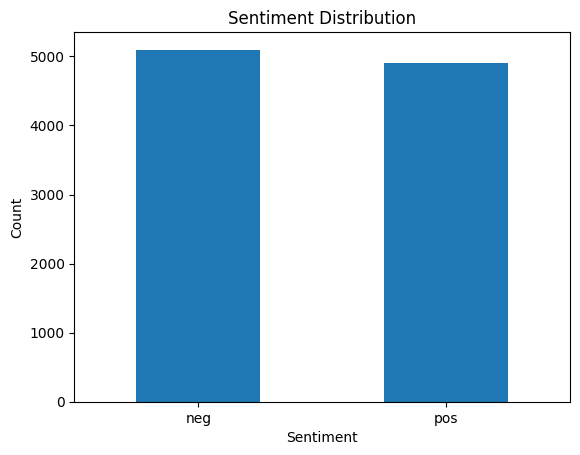

In [9]:
#Sentiment Distribution
# Count plot
df['label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Rotate labels (optional for clarity)
plt.xticks(rotation=0)

plt.show()

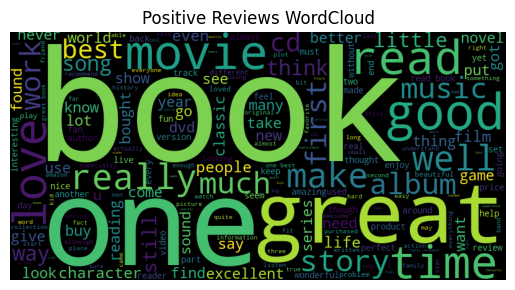

In [10]:
#Word Cloud (Positive Reviews)
positive_text = " ".join(df[df['label']=='pos']['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

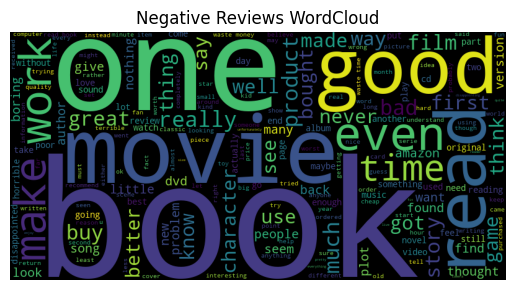

In [11]:
#Word Cloud (Negative Reviews)
negative_text = " ".join(df[df['label']=='neg']['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

#### Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [14]:
#Feature Extraction (TF-IDF)
# Convert text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])
y = df['label']

In [15]:
#Train-Test Split (Validation)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#Logistic Regression Model
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

#### Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score


In [17]:
#Evaluation 
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred, pos_label='pos')

# Classification report
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)

Accuracy: 0.851
F1 Score: 0.8443051201671892

Classification Report:
               precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [19]:
#Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

Cross-validation scores: [0.8595 0.83   0.827  0.8455 0.8505]
Average CV Score: 0.8424999999999999
